# Traffic Sign Detection for Self-Driving Cars — YOLO vs DETR

A single, run-top-to-bottom pipeline comparing **YOLO** (one-stage CNN) and **DETR**
(transformer) for traffic-sign object detection.

**Dataset:** [pkdarabi/cardetection](https://www.kaggle.com/datasets/pkdarabi/cardetection/data)
— *Traffic Signs Detection* (15 classes). Despite the URL name, the task is traffic-**sign**
detection, not car detection.

**How to use this notebook:** open it in Google Colab (GPU runtime recommended for training),
then run the cells in order. Section 0 sets everything up; later sections inspect the data,
run EDA, and train/evaluate the two baselines.

| Section | What it does | Status |
|---|---|---|
| 0 | Environment setup + dataset download | ✅ |
| 1 | Dataset inspection + annotated samples | ✅ |
| 2 | Exploratory Data Analysis | ✅ |
| 3 | Data quality assessment | ✅ |
| 4 | YOLO baseline (train + evaluate) | ✅ |
| 5 | DETR baseline (train + evaluate) | ⏳ WIP |
| 6 | YOLO vs DETR comparison | ⏳ WIP |

> ⏳ **WIP** sections call `src/` modules that are still being implemented. The cells are in
> place and will run as soon as those modules land — see `TODO.md`.

## 0 · Setup

Mount Drive, clone the repo, install dependencies, and download the dataset.
**Run this once per Colab session before anything else.**

### 0.1 Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 0.2 Clone the repo + make `src` importable

In [2]:
import os, sys, subprocess

GITHUB_REPO = 'https://github.com/huynhphtloi/traffic-sign-detection-yolo-detr'
DRIVE_ROOT  = '/content/drive/MyDrive/MasterProjects/DeepLearning/traffic-sign-detection-yolo-detr'
REPO        = '/content/traffic-sign-detection-yolo-detr'
DATA_DIR    = f'{DRIVE_ROOT}/dataset'

if not os.path.exists(REPO):
    result = subprocess.run(['git', 'clone', GITHUB_REPO, REPO])
    if result.returncode != 0:
        raise RuntimeError('git clone failed — check the repo URL or network access')
else:
    subprocess.run(['git', '-C', REPO, 'pull'], check=True)

if not os.path.exists(f'{REPO}/src'):
    raise RuntimeError(f'Clone succeeded but src/ not found in {REPO} — check the repo structure')

os.environ['TSD_DRIVE_ROOT'] = DRIVE_ROOT
os.environ['TSD_REPO_ROOT']  = REPO
os.environ['TSD_DATA_DIR']   = DATA_DIR
if REPO not in sys.path:
    sys.path.insert(0, REPO)

print('drive root:', DRIVE_ROOT)
print('repo root :', REPO)
print('data dir  :', DATA_DIR)
print('src found :', os.path.exists(f'{REPO}/src'))

drive root: /content/drive/MyDrive/MasterProjects/DeepLearning/traffic-sign-detection-yolo-detr
repo root : /content/traffic-sign-detection-yolo-detr
data dir  : /content/drive/MyDrive/MasterProjects/DeepLearning/traffic-sign-detection-yolo-detr/dataset
src found : True


### 0.3 Install dependencies

In [3]:
import os
REPO = os.environ['TSD_REPO_ROOT']
!pip install -q -r {REPO}/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 50.8 MB/s eta 0:00:00


### 0.4 Dataset source

Choose **one** source for the dataset and set `DATASET_SOURCE` in the cell below.

| Value | When to use |
|---|---|
| `'kaggle'` | First run — downloads fresh from Kaggle (requires `kaggle.json` on Drive) |
| `'drive'` | Dataset already saved on Drive — fastest, no re-download |

In [4]:
import os

DRIVE_ROOT = os.environ['TSD_DRIVE_ROOT']
DATA_DIR   = os.environ['TSD_DATA_DIR']

# ── Pick your source ────────────────────────────────────────────────────────
DATASET_SOURCE = 'kaggle'   # 'kaggle'  or  'drive'

# Used only when DATASET_SOURCE == 'drive':
# Absolute Drive path to the folder that already contains data.yaml + train/valid/test/
DRIVE_DATASET_PATH = f'{DRIVE_ROOT}/dataset/raw'

# ────────────────────────────────────────────────────────────────────────────
if DATASET_SOURCE == 'kaggle':
    print(f'Source : kaggle  (pkdarabi/cardetection → {DATA_DIR}/raw)')
elif DATASET_SOURCE == 'drive':
    print(f'Source : drive   ({DRIVE_DATASET_PATH})')
else:
    raise ValueError(f'DATASET_SOURCE must be "kaggle" or "drive", got {DATASET_SOURCE!r}')

Source : kaggle  (pkdarabi/cardetection → /content/drive/MyDrive/MasterProjects/DeepLearning/traffic-sign-detection-yolo-detr/dataset/raw)


### 0.5 Download / locate dataset

- **Kaggle**: installs credentials from Drive, then downloads and unzips the dataset (~300 MB).  
  Requires `kaggle.json` stored at your Drive project root (same folder as `DRIVE_ROOT`).
- **Drive**: symlinks your pre-downloaded dataset folder into the local workspace — no download needed.  
  Make sure `DRIVE_DATASET_PATH` in cell 0.4 points to the folder containing `data.yaml`.

In [5]:
import os, pathlib, shutil
from google.colab import files

DATA_DIR   = os.environ['TSD_DATA_DIR']
DRIVE_ROOT = os.environ['TSD_DRIVE_ROOT']

os.makedirs(f'{DATA_DIR}/raw', exist_ok=True)

if DATASET_SOURCE == 'kaggle':
    # upload kaggle.json via Colab file picker
    print('A file picker will appear — select your kaggle.json')
    uploaded = files.upload()
    if 'kaggle.json' not in uploaded:
        raise ValueError('You must upload a file named kaggle.json')
    os.makedirs('/root/.kaggle', exist_ok=True)
    with open('/root/.kaggle/kaggle.json', 'wb') as f:
        f.write(uploaded['kaggle.json'])
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('kaggle.json installed')
    !kaggle datasets download -d pkdarabi/cardetection -p {DATA_DIR}/raw --unzip

elif DATASET_SOURCE == 'drive':
    src = pathlib.Path(DRIVE_DATASET_PATH)
    if not src.exists():
        raise FileNotFoundError(
            f'Drive dataset not found: {DRIVE_DATASET_PATH}\n'
            'Update DRIVE_DATASET_PATH in cell 0.4 to the folder containing data.yaml.'
        )
    link = pathlib.Path(DATA_DIR) / 'raw' / src.name
    if not link.exists():
        link.symlink_to(src.resolve())
        print(f'Linked  {link}')
        print(f'     -> {src.resolve()}')
    else:
        print(f'Already linked: {link}')

!ls {DATA_DIR}/raw

A file picker will appear — select your kaggle.json


Saving kaggle.json to kaggle.json
kaggle.json installed
Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)
100% 99.8M/99.8M [00:06<00:00, 15.7MB/s]

car  video.mp4


### 0.6 Organise into `data/processed/cardetection/`

The Roboflow export unzips to a single subfolder. This finds it and symlinks it to
`data/processed/cardetection` so every script resolves to the same root.

In [6]:
import os, pathlib

DATA_DIR = pathlib.Path(os.environ['TSD_DATA_DIR'])
raw = DATA_DIR / 'raw'
processed = DATA_DIR / 'processed' / 'cardetection'

# Find the subfolder that contains data.yaml (the Roboflow export root).
export_root = None
for candidate in [raw, *raw.iterdir()]:
    if (candidate / 'data.yaml').exists():
        export_root = candidate
        break

if export_root is None:
    raise FileNotFoundError('Could not locate data.yaml under data/raw — check the download.')

processed.parent.mkdir(parents=True, exist_ok=True)
if not processed.exists():
    processed.symlink_to(export_root.resolve())
    print(f'symlinked {processed} -> {export_root}')
else:
    print(f'already exists: {processed}')

for split in ('train', 'valid', 'test'):
    imgs = list((processed / split / 'images').glob('*')) if (processed / split / 'images').exists() else []
    print(f'  {split}: {len(imgs)} images')

symlinked /content/drive/MyDrive/MasterProjects/DeepLearning/traffic-sign-detection-yolo-detr/dataset/processed/cardetection -> /content/drive/MyDrive/MasterProjects/DeepLearning/traffic-sign-detection-yolo-detr/dataset/raw/car
  train: 3530 images
  valid: 801 images
  test: 638 images


## 1 · Dataset Inspection

Detect the dataset layout/format, counts, classes, and splits — **without assuming** — then
render annotated samples. Writes `results/tables/dataset_summary.csv` and syncs `configs/*.yaml`.

### 1.1 Inspect structure + sync configs

In [7]:
from src.data.inspect_dataset import inspect, write_configs
from src.utils.paths import DATA_PROCESSED
df = inspect(DATA_PROCESSED)
write_configs(DATA_PROCESSED)   # regenerate configs/classes.yaml + data.yaml from data.yaml
df

[inspect] train: 3530 images — counting labels...
[inspect]   train: 500/3530 done
[inspect]   train: 1000/3530 done
[inspect]   train: 1500/3530 done
[inspect]   train: 2000/3530 done
[inspect]   train: 2500/3530 done
[inspect]   train: 3000/3530 done
[inspect]   train: 3500/3530 done
[inspect] train: 3530 label files, 4298 boxes
[inspect] valid: 801 images — counting labels...
[inspect]   valid: 500/801 done
[inspect] valid: 801 label files, 944 boxes
[inspect] test: 638 images — counting labels...
[inspect]   test: 500/638 done
[inspect] test: 638 label files, 770 boxes
[write-configs] synced /content/traffic-sign-detection-yolo-detr/configs/classes.yaml and /content/traffic-sign-detection-yolo-detr/configs/data.yaml (15 classes)


,split,exists,images,label_files,boxes,format,num_classes
0,train,True,3530,3530,4298,YOLO TXT (Roboflow/Ultralytics),15
1,valid,True,801,801,944,YOLO TXT (Roboflow/Ultralytics),15
2,test,True,638,638,770,YOLO TXT (Roboflow/Ultralytics),15


### 1.2 Annotated samples (required before training)

[visualize] 1/12 — 000235_jpg.rf.58009e601f129b35cbbb2dbb6336cfc2.jpg
[visualize] 2/12 — FisheyeCamera_1_00497_png.rf.241cc03642cdc931bcb50b1c4947595f.jpg
[visualize] 3/12 — FisheyeCamera_1_00037_png.rf.d53f485532f8b13198f33f1d91c4a49f.jpg
[visualize] 4/12 — 001466_jpg.rf.5f1e09ac149f516e67ac48f70c3b761d.jpg
[visualize] 5/12 — 00005_00027_00014_png.rf.354f184dc18038e7d5e51edca842a27e.jpg
[visualize] 6/12 — FisheyeCamera_1_00223_png.rf.b4ceca7a7093f72a7c0c50e12408dcb1.jpg
[visualize] 7/12 — road545_png.rf.02614a36cb366d36c8c23deca405fc02.jpg
[visualize] 8/12 — 00008_00034_00007_png.rf.08a62227cc74501de6baeb62505431db.jpg
[visualize] 9/12 — FisheyeCamera_1_00641_png.rf.70f3b246fc151f31ad2d0eda859a929b.jpg
[visualize] 10/12 — 000430_jpg.rf.1008366e8e2805837605a83fc64bc470.jpg
[visualize] 11/12 — 00004_00038_00010_png.rf.ccb068d57bc46d80e2e13f92a9dffca7.jpg
[visualize] 12/12 — 000796_jpg.rf.f53632340c6f9441e54f4da49904cf97.jpg
[visualize] done — wrote 12 annotated images to /content/traffi

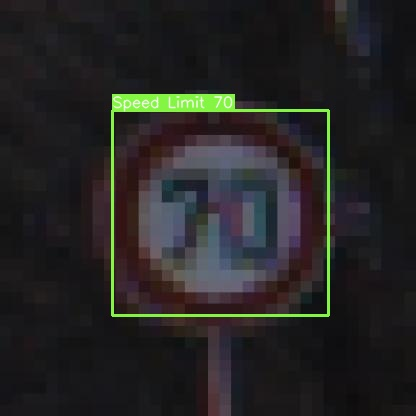

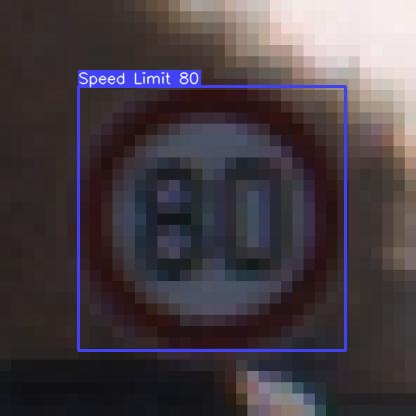

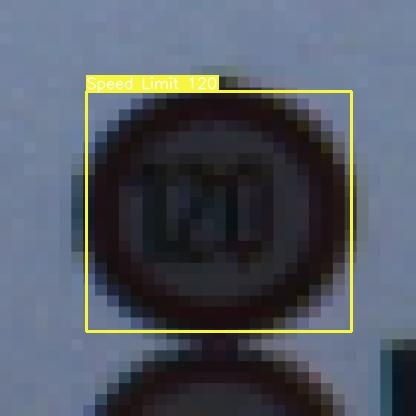

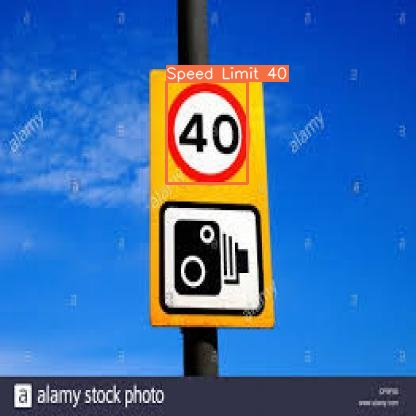

In [10]:
from src.data.visualize_annotations import visualize
out = visualize('train', n=12)
from IPython.display import Image, display
import os
for f in sorted(os.listdir(out))[:4]:
    display(Image(filename=str(out / f)))

## 2 · Exploratory Data Analysis

Class distribution + imbalance, bounding-box statistics, image statistics, and the
object-center heatmap. Saves plots to `results/eda/` and tables to `results/tables/`.



In [11]:
from src.eda.class_distribution import run as class_dist; class_dist()
from src.eda.bbox_statistics import run as bbox_stats; bbox_stats()
from src.eda.image_statistics import run as image_stats; image_stats()
from src.eda.heatmap_analysis import run as heatmap; heatmap()

from IPython.display import Image, display
import glob
from src.utils.paths import RESULTS_EDA

# Display all generated EDA plots
for img_path in sorted(RESULTS_EDA.glob('*.png')):
    print(f'\n--- {img_path.name} ---')
    display(Image(filename=str(img_path)))


ImportError: cannot import name 'run' from 'src.eda.class_distribution' (/content/traffic-sign-detection-yolo-detr/src/eda/class_distribution.py)

## 3 · Data Quality Assessment

Quality report (missing/empty/invalid/corrupt/duplicate) plus a difficult-sample gallery
(small / blurry / low-light signs).



In [ ]:
from src.data.validate_labels import validate, summarize
from src.utils.paths import DATA_PROCESSED

rep = validate(DATA_PROCESSED)
print(summarize(rep))
rep.head()


## 4 · YOLO Baseline

Train YOLOv8n (pretrained, imgsz 640, flip-LR OFF) and evaluate on the test split.
**Needs a GPU.** Writes `weights/yolo/yolo_baseline/best.pt` and
`results/metrics/yolo_baseline.json`.

### 4.1 Train

In [ ]:
from src.training.train_yolo import train
results, best = train(model='yolov8n.pt', epochs=30, name='yolo_baseline')
print('best checkpoint:', best)

### 4.2 Evaluate on the test split (mAP, P, R, FPS, size) → metrics JSON

In [ ]:
from src.evaluation.evaluate_yolo import evaluate
from src.utils.paths import RESULTS_METRICS, ensure_dir
import json
metrics = evaluate(best, split='test')
ensure_dir(RESULTS_METRICS)
(RESULTS_METRICS / 'yolo_baseline.json').write_text(json.dumps(metrics, indent=2))
metrics

### 4.3 Training curves

In [ ]:
from IPython.display import Image
from src.utils.paths import WEIGHTS_YOLO
Image(filename=str(WEIGHTS_YOLO / 'yolo_baseline' / 'training_curves.png'))

## 5 · DETR Baseline

Convert to COCO, fine-tune `facebook/detr-resnet-50` (lightweight: batch 2, ~10 epochs),
and evaluate. **Needs a GPU.**

> ⏳ **Work in progress.** Runs once `src/data/convert_to_coco.py`, `src/training/train_detr.py`,
> and `src/evaluation/evaluate_detr.py` are implemented (see `TODO.md`).

In [ ]:
# from src.data.convert_to_coco import convert; convert()
# from src.training.train_detr import train; model_dir = train(epochs=10, batch=2, name='detr_baseline')
# from src.evaluation.evaluate_detr import evaluate
# from src.utils.paths import RESULTS_METRICS, ensure_dir
# import json
# m = evaluate(model_dir, split='test')
# ensure_dir(RESULTS_METRICS); (RESULTS_METRICS / 'detr_baseline.json').write_text(json.dumps(m, indent=2)); m

## 6 · YOLO vs DETR Comparison

Collect both metrics JSONs into the initial comparison table → `results/tables/comparison.csv`.

> ⏳ **Work in progress.** Runs once `src/evaluation/compare_models.py` is implemented (see `TODO.md`).

In [ ]:
# from src.evaluation.compare_models import compare
# from src.utils.paths import RESULTS_TABLES, ensure_dir
# df = compare(); ensure_dir(RESULTS_TABLES); df.to_csv(RESULTS_TABLES / 'comparison.csv', index=False); df